In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
random.seed(42)

agencies = [
    "DBT",
    "DST",
    "BIRAC",
    "ICMR",
    "CSIR",
    "ANRF",
    "WHO",
    "NIH",
    "Gates Foundation"
]

research_areas = [
    "Biotechnology",
    "Genomics",
    "Vaccines",
    "Drug Discovery",
    "Public Health",
    "Bioinformatics",
    "Cancer Research",
    "Immunology",
    "Agricultural Biotechnology",
    "Precision Medicine"
]

grant_titles = [
    "Innovative Research Grant",
    "Young Investigator Award",
    "Precision Medicine Initiative",
    "Translational Research Program",
    "Health Innovation Program",
    "Strategic Research Scheme",
    "Genomics Research Fund",
    "International Collaboration Grant"
]

eligibility = [
    "Faculty",
    "Universities",
    "Research Institutes",
    "Faculty + Scientists",
    "Startups"
]

status = [
    "Open",
    "Under Review",
    "Closed"
]

records = []

for i in range(1,151):

    agency = random.choice(agencies)

    area = random.choice(research_areas)

    grant = random.choice(grant_titles)

    amount = random.randint(10,500)*100000

    deadline = (
        datetime.today() +
        timedelta(days=random.randint(30,365))
    ).date()

    duration = random.choice(
        [12,24,36,48,60]
    )

    records.append([
        i,
        agency,
        grant,
        amount,
        area,
        deadline,
        random.choice(eligibility),
        duration,
        random.choice(status)
    ])

grants_df = pd.DataFrame(
    records,
    columns=[
        "Grant_ID",
        "Agency",
        "Grant_Name",
        "Funding_Amount",
        "Research_Area",
        "Deadline",
        "Eligibility",
        "Duration_Months",
        "Status"
    ]
)

grants_df.head()

,Grant_ID,Agency,Grant_Name,Funding_Amount,Research_Area,Deadline,Eligibility,Duration_Months,Status
0,1,DST,Health Innovation Program,13500000,Biotechnology,2026-11-09,Faculty,24,Closed
1,2,Gates Foundation,Genomics Research Fund,2600000,Genomics,2026-08-02,Universities,12,Open
2,3,Gates Foundation,Innovative Research Grant,29700000,Precision Medicine,2026-10-27,Faculty + Scientists,60,Open
3,4,NIH,Health Innovation Program,42400000,Precision Medicine,2026-07-21,Faculty + Scientists,24,Under Review
4,5,CSIR,Translational Research Program,50000000,Vaccines,2027-01-06,Faculty,12,Under Review


In [3]:
grants_df.to_csv(
    "grants_raw.csv",
    index=False
)

print("Dataset Saved")
print("Total Grants:", len(grants_df))

Dataset Saved
Total Grants: 150


In [4]:
grants_df.describe(include='all')

,Grant_ID,Agency,Grant_Name,Funding_Amount,Research_Area,Deadline,Eligibility,Duration_Months,Status
count,150.000000,150,150,1.500000e+02,150,150,150,150.000000,150
unique,NaN,9,8,NaN,10,123,5,NaN,3
top,NaN,NIH,Health Innovation Program,NaN,Immunology,2026-11-30,Faculty,NaN,Closed
freq,NaN,24,25,NaN,25,4,34,NaN,55
mean,75.500000,NaN,NaN,2.591800e+07,NaN,NaN,NaN,35.200000,NaN
std,43.445368,NaN,NaN,1.391840e+07,NaN,NaN,NaN,17.622438,NaN
min,1.000000,NaN,NaN,1.100000e+06,NaN,NaN,NaN,12.000000,NaN
25%,38.250000,NaN,NaN,1.342500e+07,NaN,NaN,NaN,24.000000,NaN
50%,75.500000,NaN,NaN,2.685000e+07,NaN,NaN,NaN,36.000000,NaN
75%,112.750000,NaN,NaN,3.712500e+07,NaN,NaN,NaN,48.000000,NaN


In [5]:
agency_summary = (
    grants_df.groupby("Agency")
    ["Funding_Amount"]
    .sum()
    .sort_values(ascending=False)
)

agency_summary

Agency
NIH                 644800000
DBT                 501400000
DST                 495400000
Gates Foundation    434500000
ICMR                433000000
ANRF                391700000
CSIR                354900000
BIRAC               353300000
WHO                 278700000
Name: Funding_Amount, dtype: int64

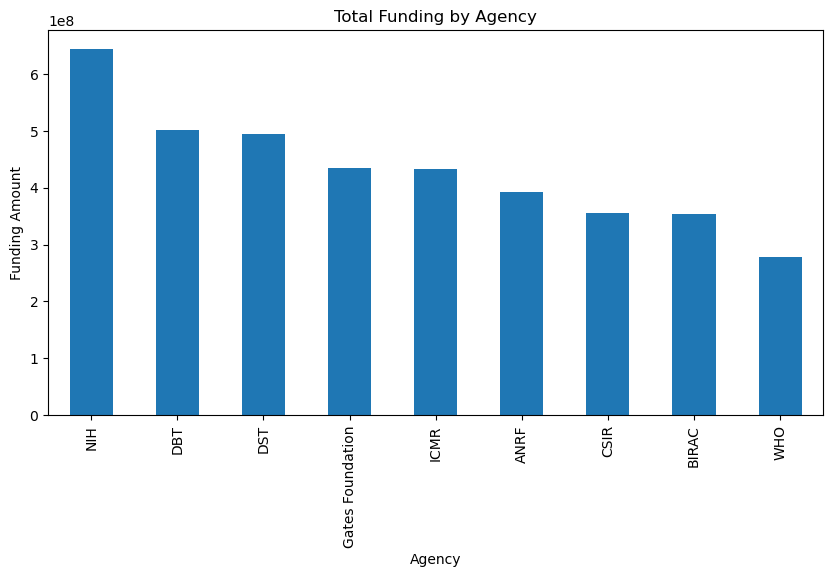

In [6]:
import matplotlib.pyplot as plt

agency_summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Total Funding by Agency"
)

plt.ylabel(
    "Funding Amount"
)

plt.show()

In [7]:
grants_df["Deadline"] = pd.to_datetime(
    grants_df["Deadline"]
)

upcoming = (
    grants_df.sort_values(
        "Deadline"
    )
    .head(10)
)

upcoming[
    [
        "Grant_Name",
        "Agency",
        "Deadline",
        "Funding_Amount"
    ]
]

,Grant_Name,Agency,Deadline,Funding_Amount
76,Genomics Research Fund,DBT,2026-07-21,25400000
3,Health Innovation Program,NIH,2026-07-21,42400000
49,Genomics Research Fund,NIH,2026-07-22,29700000
17,Health Innovation Program,NIH,2026-07-23,29300000
96,International Collaboration Grant,NIH,2026-07-26,41500000
1,Genomics Research Fund,Gates Foundation,2026-08-02,2600000
111,International Collaboration Grant,WHO,2026-08-03,15900000
80,International Collaboration Grant,WHO,2026-08-12,10300000
11,Strategic Research Scheme,Gates Foundation,2026-08-15,44100000
34,Genomics Research Fund,NIH,2026-08-17,47200000


In [8]:
faculty_interest = "Biotechnology"

matches = grants_df[
    grants_df["Research_Area"]
    == faculty_interest
]

matches[
    [
        "Grant_Name",
        "Agency",
        "Funding_Amount",
        "Deadline"
    ]
].head(10)

,Grant_Name,Agency,Funding_Amount,Deadline
0,Health Innovation Program,DST,13500000,2026-11-09
30,Genomics Research Fund,DST,38200000,2027-01-07
33,Young Investigator Award,Gates Foundation,48400000,2026-11-16
37,Innovative Research Grant,ANRF,30900000,2027-03-19
45,Health Innovation Program,Gates Foundation,48700000,2026-09-09
56,Translational Research Program,ICMR,21400000,2027-01-02
60,Translational Research Program,WHO,19600000,2027-02-23
79,Genomics Research Fund,Gates Foundation,31300000,2027-05-02
83,Innovative Research Grant,DST,49600000,2026-11-21
89,Genomics Research Fund,ANRF,43100000,2027-03-25


In [9]:
import sqlite3

conn = sqlite3.connect("grants.db")

grants_df.to_sql(
    "Grants",
    conn,
    if_exists="replace",
    index=False
)

print("Database Created Successfully")

Database Created Successfully


In [10]:
query = """
SELECT *
FROM Grants
LIMIT 5
"""

pd.read_sql(query, conn)

,Grant_ID,Agency,Grant_Name,Funding_Amount,Research_Area,Deadline,Eligibility,Duration_Months,Status
0,1,DST,Health Innovation Program,13500000,Biotechnology,2026-11-09 00:00:00,Faculty,24,Closed
1,2,Gates Foundation,Genomics Research Fund,2600000,Genomics,2026-08-02 00:00:00,Universities,12,Open
2,3,Gates Foundation,Innovative Research Grant,29700000,Precision Medicine,2026-10-27 00:00:00,Faculty + Scientists,60,Open
3,4,NIH,Health Innovation Program,42400000,Precision Medicine,2026-07-21 00:00:00,Faculty + Scientists,24,Under Review
4,5,CSIR,Translational Research Program,50000000,Vaccines,2027-01-06 00:00:00,Faculty,12,Under Review


In [11]:
query = """
SELECT
    Grant_Name,
    Agency,
    Funding_Amount
FROM Grants
ORDER BY Funding_Amount DESC
LIMIT 10
"""

top_funding = pd.read_sql(query, conn)

top_funding

,Grant_Name,Agency,Funding_Amount
0,Translational Research Program,CSIR,50000000
1,Strategic Research Scheme,BIRAC,49600000
2,Innovative Research Grant,DST,49600000
3,Young Investigator Award,DBT,49500000
4,Young Investigator Award,ICMR,49200000
5,Health Innovation Program,Gates Foundation,48700000
6,Strategic Research Scheme,CSIR,48500000
7,Innovative Research Grant,DST,48500000
8,Young Investigator Award,Gates Foundation,48400000
9,Genomics Research Fund,NIH,47200000


In [12]:
query = """
SELECT
    Agency,
    SUM(Funding_Amount) AS Total_Funding
FROM Grants
GROUP BY Agency
ORDER BY Total_Funding DESC
"""

agency_funding = pd.read_sql(query, conn)

agency_funding

,Agency,Total_Funding
0,NIH,644800000
1,DBT,501400000
2,DST,495400000
3,Gates Foundation,434500000
4,ICMR,433000000
5,ANRF,391700000
6,CSIR,354900000
7,BIRAC,353300000
8,WHO,278700000


In [13]:
query = """
SELECT *
FROM Grants
WHERE Status = 'Open'
"""

open_grants = pd.read_sql(query, conn)

open_grants.head()

,Grant_ID,Agency,Grant_Name,Funding_Amount,Research_Area,Deadline,Eligibility,Duration_Months,Status
0,2,Gates Foundation,Genomics Research Fund,2600000,Genomics,2026-08-02 00:00:00,Universities,12,Open
1,3,Gates Foundation,Innovative Research Grant,29700000,Precision Medicine,2026-10-27 00:00:00,Faculty + Scientists,60,Open
2,8,ICMR,Innovative Research Grant,34800000,Genomics,2026-11-11 00:00:00,Faculty,36,Open
3,16,ANRF,Precision Medicine Initiative,27000000,Drug Discovery,2027-03-27 00:00:00,Faculty,12,Open
4,21,ICMR,Strategic Research Scheme,40000000,Vaccines,2026-10-08 00:00:00,Startups,60,Open


In [14]:
query = """
SELECT
    Research_Area,
    COUNT(*) AS Number_of_Grants,
    SUM(Funding_Amount) AS Total_Funding
FROM Grants
GROUP BY Research_Area
ORDER BY Total_Funding DESC
"""

area_analysis = pd.read_sql(query, conn)

area_analysis

,Research_Area,Number_of_Grants,Total_Funding
0,Immunology,25,592700000
1,Drug Discovery,17,478900000
2,Biotechnology,13,463700000
3,Agricultural Biotechnology,17,449100000
4,Public Health,18,444100000
5,Genomics,14,329500000
6,Precision Medicine,12,318600000
7,Cancer Research,13,306100000
8,Bioinformatics,9,259300000
9,Vaccines,12,245700000


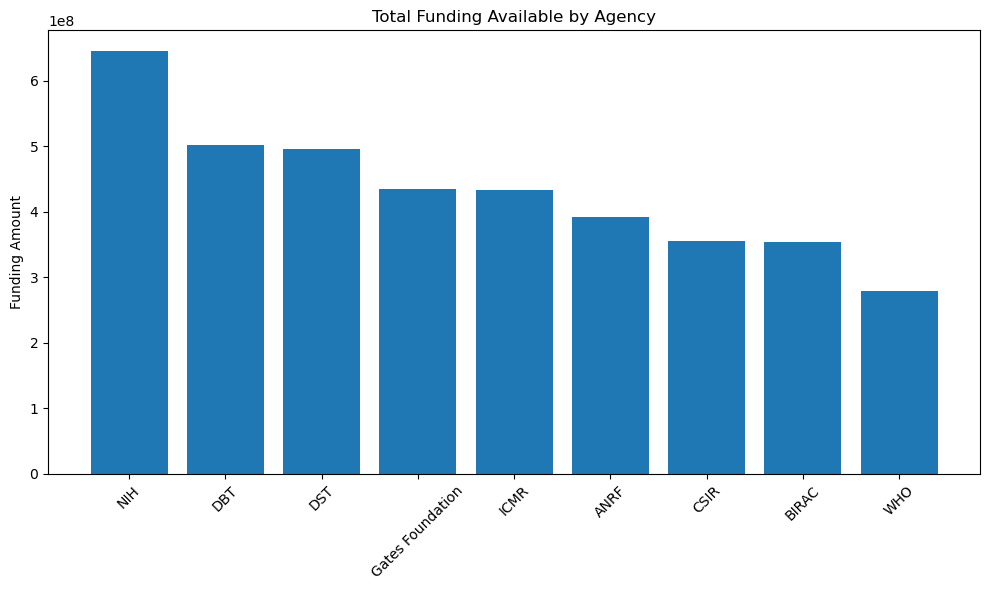

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    agency_funding["Agency"],
    agency_funding["Total_Funding"]
)

plt.xticks(rotation=45)

plt.title(
    "Total Funding Available by Agency"
)

plt.ylabel("Funding Amount")

plt.tight_layout()

plt.show()

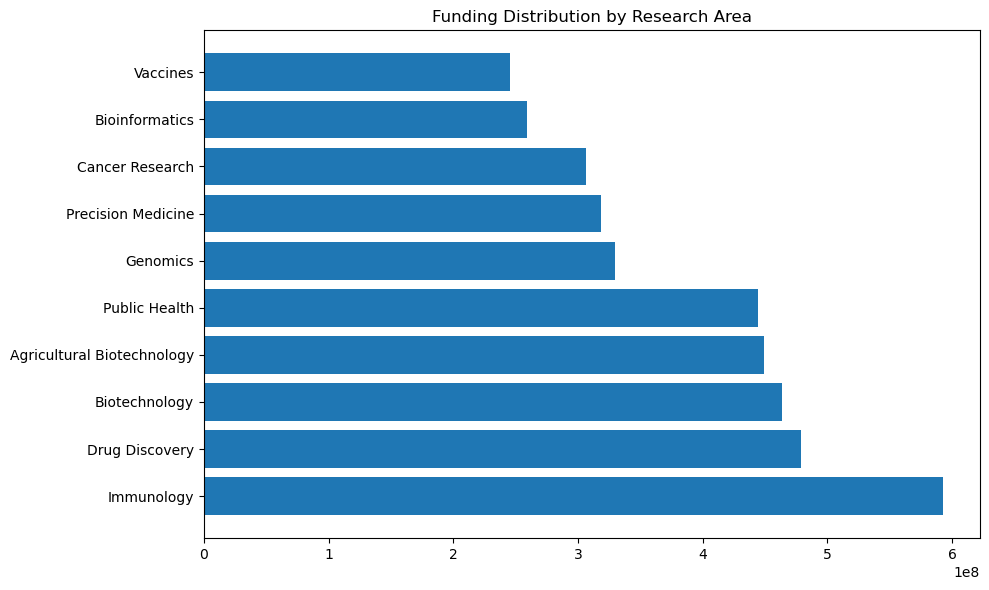

In [16]:
plt.figure(figsize=(10,6))

plt.barh(
    area_analysis["Research_Area"],
    area_analysis["Total_Funding"]
)

plt.title(
    "Funding Distribution by Research Area"
)

plt.tight_layout()

plt.show()

In [17]:
total_grants = len(grants_df)

total_funding = grants_df[
    "Funding_Amount"
].sum()

open_grants_count = len(
    grants_df[
        grants_df["Status"]=="Open"
    ]
)

avg_grant_value = grants_df[
    "Funding_Amount"
].mean()

print("===== EXECUTIVE KPI SUMMARY =====")
print()

print("Total Grants:", total_grants)

print("Total Funding:",
      f"₹{total_funding:,.0f}")

print("Open Opportunities:",
      open_grants_count)

print("Average Grant Value:",
      f"₹{avg_grant_value:,.0f}")

===== EXECUTIVE KPI SUMMARY =====

Total Grants: 150
Total Funding: ₹3,887,700,000
Open Opportunities: 51
Average Grant Value: ₹25,918,000


In [18]:
faculty_profiles = pd.DataFrame({

    "Faculty_Name": [
        "Dr. Sharma",
        "Dr. Patel",
        "Dr. Singh",
        "Dr. Mehta",
        "Dr. Joshi"
    ],

    "Research_Area": [
        "Biotechnology",
        "Cancer Research",
        "Immunology",
        "Bioinformatics",
        "Genomics"
    ]

})

faculty_profiles

,Faculty_Name,Research_Area
0,Dr. Sharma,Biotechnology
1,Dr. Patel,Cancer Research
2,Dr. Singh,Immunology
3,Dr. Mehta,Bioinformatics
4,Dr. Joshi,Genomics


In [19]:
faculty_name = "Dr. Sharma"

faculty_area = faculty_profiles[
    faculty_profiles["Faculty_Name"]
    == faculty_name
]["Research_Area"].iloc[0]

recommended_grants = grants_df[
    grants_df["Research_Area"]
    == faculty_area
]

recommended_grants[
    [
        "Grant_Name",
        "Agency",
        "Funding_Amount",
        "Deadline"
    ]
].head(10)

,Grant_Name,Agency,Funding_Amount,Deadline
0,Health Innovation Program,DST,13500000,2026-11-09
30,Genomics Research Fund,DST,38200000,2027-01-07
33,Young Investigator Award,Gates Foundation,48400000,2026-11-16
37,Innovative Research Grant,ANRF,30900000,2027-03-19
45,Health Innovation Program,Gates Foundation,48700000,2026-09-09
56,Translational Research Program,ICMR,21400000,2027-01-02
60,Translational Research Program,WHO,19600000,2027-02-23
79,Genomics Research Fund,Gates Foundation,31300000,2027-05-02
83,Innovative Research Grant,DST,49600000,2026-11-21
89,Genomics Research Fund,ANRF,43100000,2027-03-25


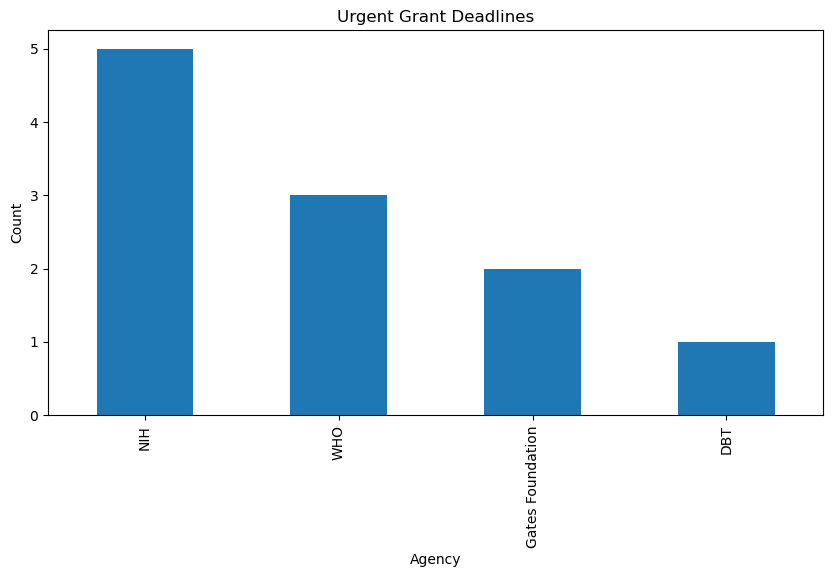

In [24]:
if len(risk_grants) > 0:

    plt.figure(figsize=(10,5))

    risk_grants["Agency"].value_counts().plot(
        kind="bar"
    )

    plt.title(
        "Urgent Grant Deadlines"
    )

    plt.ylabel("Count")

    plt.show()

else:

    print(
        "No grants found within selected deadline window."
    )

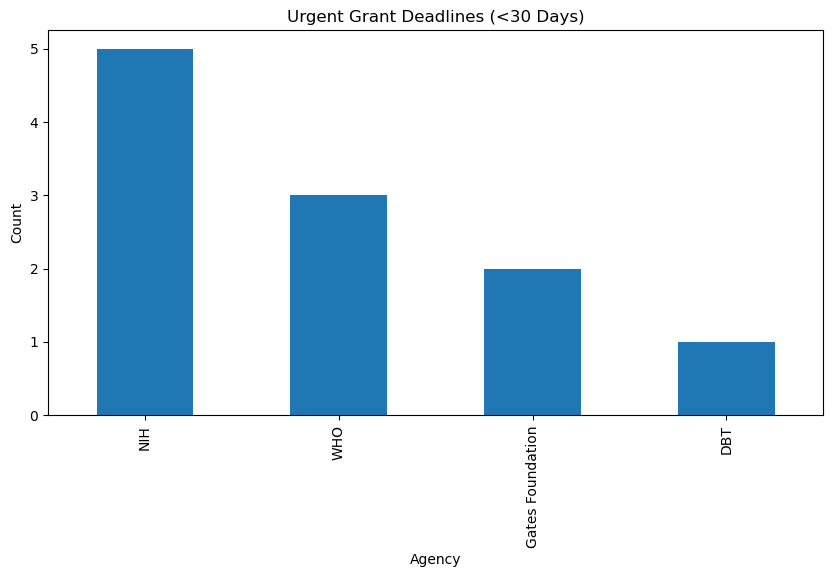

In [25]:
plt.figure(figsize=(10,5))

risk_grants["Agency"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Urgent Grant Deadlines (<30 Days)"
)

plt.ylabel("Count")

plt.show()

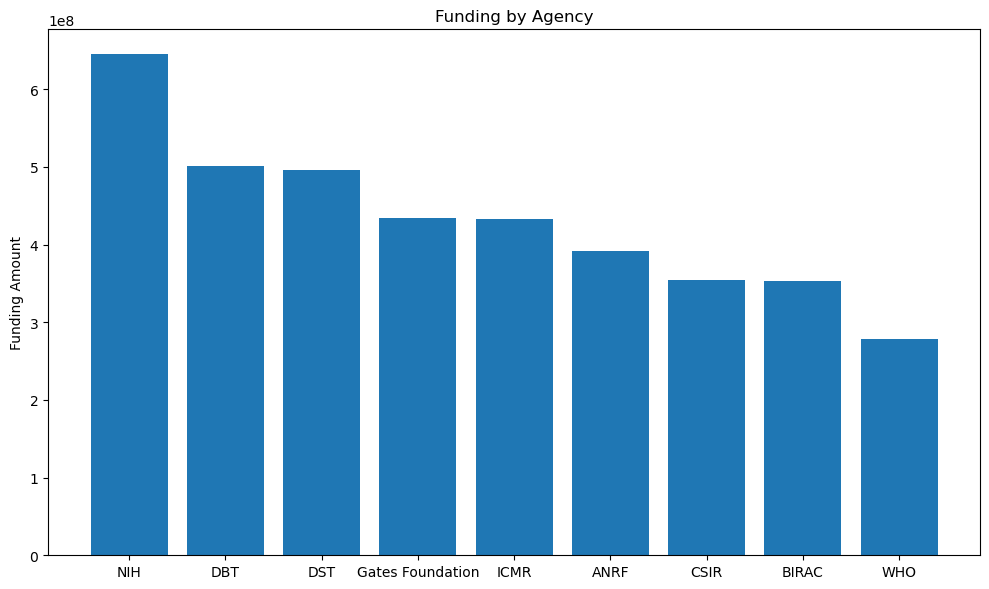

In [26]:
plt.figure(figsize=(10,6))

plt.bar(
    agency_funding["Agency"],
    agency_funding["Total_Funding"]
)

plt.title("Funding by Agency")
plt.ylabel("Funding Amount")

plt.tight_layout()

plt.savefig(
    "Agency_Funding.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

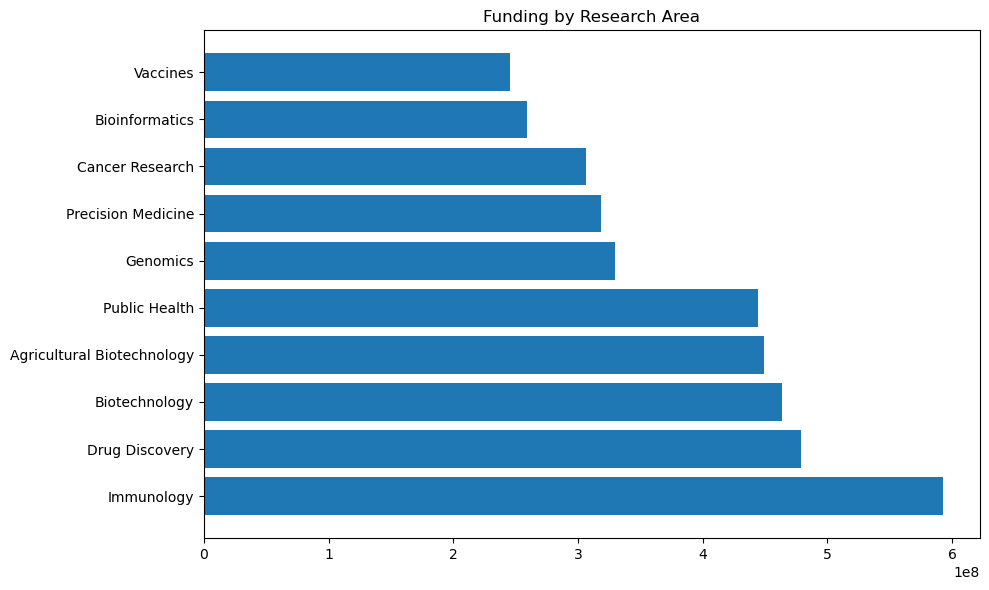

In [27]:
plt.figure(figsize=(10,6))

plt.barh(
    area_analysis["Research_Area"],
    area_analysis["Total_Funding"]
)

plt.title("Funding by Research Area")

plt.tight_layout()

plt.savefig(
    "Research_Area_Funding.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
top_agency = agency_funding.iloc[0]["Agency"]

top_funding = agency_funding.iloc[0]["Total_Funding"]

top_area = area_analysis.iloc[0]["Research_Area"]

print("EXECUTIVE INSIGHTS")
print("-"*50)

print(f"Top Funding Agency: {top_agency}")

print(f"Funding Available: ₹{top_funding:,.0f}")

print(f"Highest Funded Research Area: {top_area}")

print(
    f"Total Funding Portfolio: ₹{grants_df['Funding_Amount'].sum():,.0f}"
)

EXECUTIVE INSIGHTS
--------------------------------------------------
Top Funding Agency: NIH
Funding Available: ₹644,800,000
Highest Funded Research Area: Immunology
Total Funding Portfolio: ₹3,887,700,000


In [29]:
director_summary = f"""
Research Funding Opportunity Intelligence Report

Total Grants Tracked:
{len(grants_df)}

Total Funding Available:
₹{grants_df['Funding_Amount'].sum():,.0f}

Open Opportunities:
{len(grants_df[grants_df['Status']=='Open'])}

Top Funding Agency:
{top_agency}

Highest Funded Research Area:
{top_area}

Recommendation:
Focus funding outreach efforts toward high-value opportunities
and implement proactive deadline tracking for grants expiring
within 60 days.
"""

print(director_summary)


Research Funding Opportunity Intelligence Report

Total Grants Tracked:
150

Total Funding Available:
₹3,887,700,000

Open Opportunities:
51

Top Funding Agency:
NIH

Highest Funded Research Area:
Immunology

Recommendation:
Focus funding outreach efforts toward high-value opportunities
and implement proactive deadline tracking for grants expiring
within 60 days.



In [30]:
with open(
    "Director_Report.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(director_summary)

print("Director Report Created")

Director Report Created


In [31]:
grants_df.shape

(150, 10)

In [32]:
grants_df.to_csv(
    "Research_Funding_Dataset.csv",
    index=False
)

print("Dataset Exported Successfully")

Dataset Exported Successfully


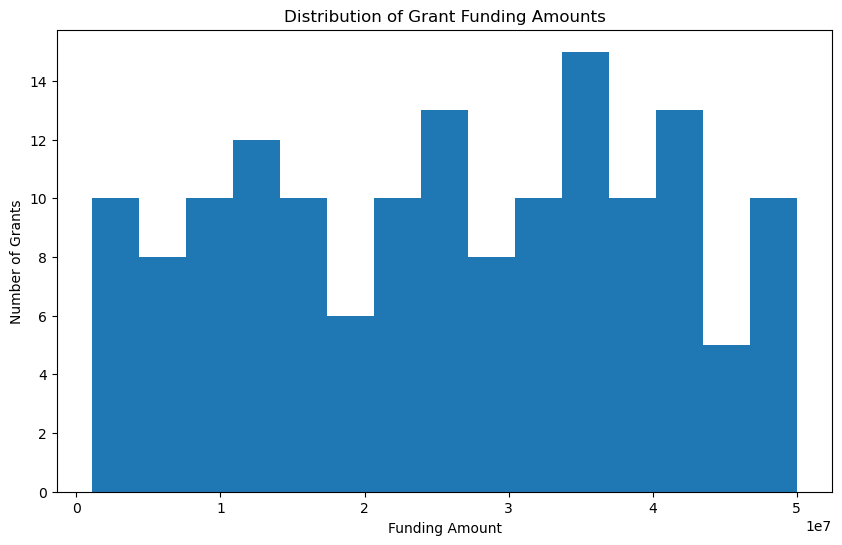

In [33]:
plt.figure(figsize=(10,6))

plt.hist(
    grants_df["Funding_Amount"],
    bins=15
)

plt.title(
    "Distribution of Grant Funding Amounts"
)

plt.xlabel("Funding Amount")

plt.ylabel("Number of Grants")

plt.show()

In [34]:
project_summary = pd.DataFrame({

    "Metric":[
        "Total Grants",
        "Funding Agencies",
        "Research Areas",
        "Total Funding"
    ],

    "Value":[
        len(grants_df),
        grants_df["Agency"].nunique(),
        grants_df["Research_Area"].nunique(),
        f"₹{grants_df['Funding_Amount'].sum():,.0f}"
    ]
})

project_summary

,Metric,Value
0,Total Grants,150
1,Funding Agencies,9
2,Research Areas,10
3,Total Funding,"₹3,887,700,000"
